# Try out different distance metrics

In [4]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import warnings
import os
import pickle
from os.path import join, isfile
from typing import Dict, List

import anndata
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
DATA_PATH = "/vol/data/dataset-similarity/preprocessed"
CACHE_DIR = "/vol/data/dataset-similarity/cache"


QUERY_DATASET = "f6c50495-3361-40ed-a819-fb9644396ed9"
REF_DATASET = "ced320a1-29f3-47c1-a735-513c7084d508_CAP"
N_TOP_GENES = 750

In [7]:
cache_file = join(
    CACHE_DIR, 
    "+".join([QUERY_DATASET, REF_DATASET, f"{N_TOP_GENES}HVGs"]) + ".pickle"
)
with open(cache_file, "rb") as f:
    adata_query, adata_ref = pickle.load(f)

In [8]:
adata_query

AnnData object with n_obs × n_vars = 263159 × 750
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'AuthorCellType', 'cell_type_author', 'sample_id'
    var: 'feature_id'
    uns: 'de_res_ova', 'de_res_ava'
    obsm: 'X_scTab', 'X_scimilarity'

In [9]:
adata_ref

AnnData object with n_obs × n_vars = 1265624 × 750
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'sample_uuid', 'author_cell_type', 'cell_type_author', 'sample_id'
    var: 'feature_id'
    uns: 'de_res_ova', 'de_res_ava'
    obsm: 'X_scTab'

## Overlap of differentially expressed genes

In [222]:
%autoreload
from datasim.label_distance import de_gene_overlap_label_distance
from datasim.plotting import plot_cluster_mapping

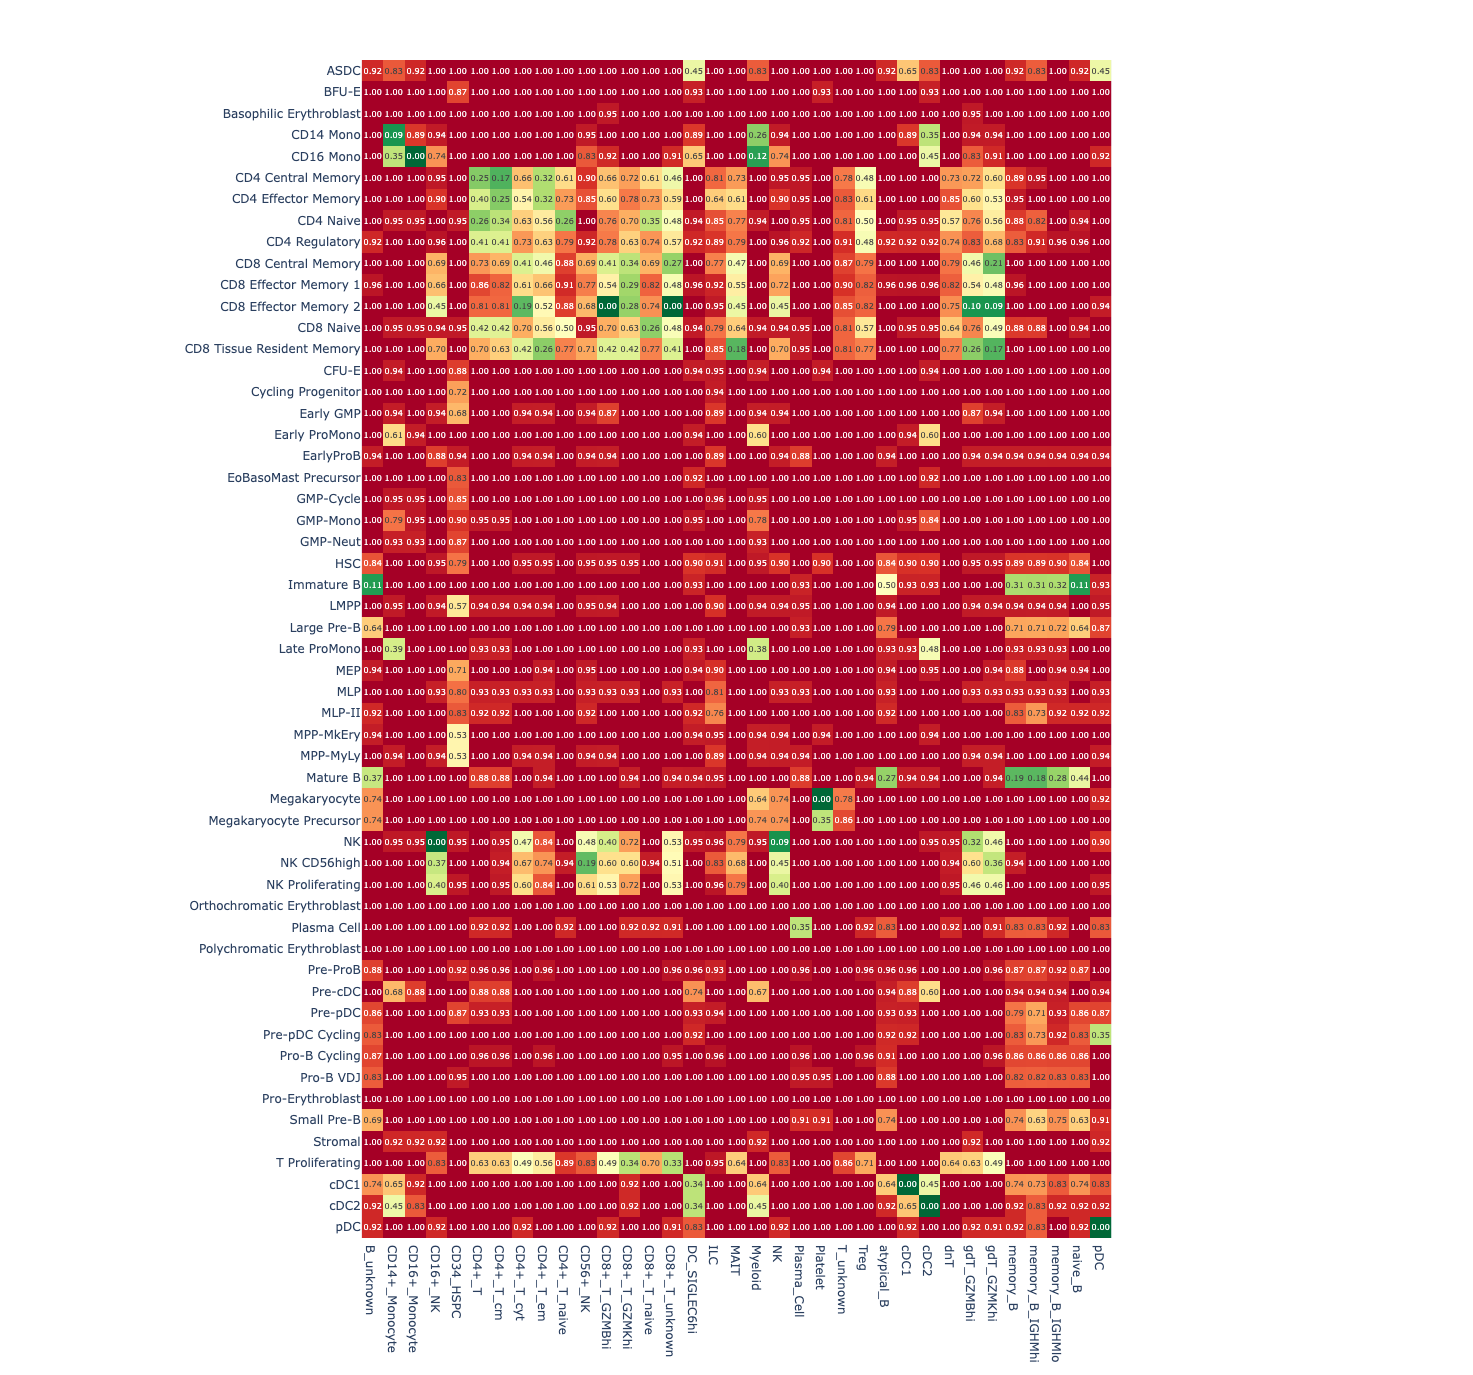

In [23]:
de_gene_overlap = de_gene_overlap_label_distance(
    adata_query,
    adata_ref,
    "cell_type_author",
    n_genes_adata1_ova=10,
    n_genes_adata2_ova=40,
    n_genes_adata1_ava=3,
    n_genes_adata2_ava=6,
    n_genes_adata1_max=None,
    n_genes_adata2_max=None,
    overlap_threshold_ava=0.3,
    overlap_n_genes_ava=10,
    adj_p_val_threshold=0.05,
    auroc_threshold=0.6,
    gene_filtering=True,
)
de_gene_overlap = de_gene_overlap.sort_index().sort_index(axis=1)

fig = plot_cluster_mapping(de_gene_overlap, zmin=0., zmax=1., colormap="RdYlGn_r", show=False)
fig.update_coloraxes(showscale=False)

## Rank overlap of DE genes

In [223]:
%autoreload
from datasim.label_distance import de_gene_rank_difference_distance
from datasim.plotting import plot_cluster_mapping

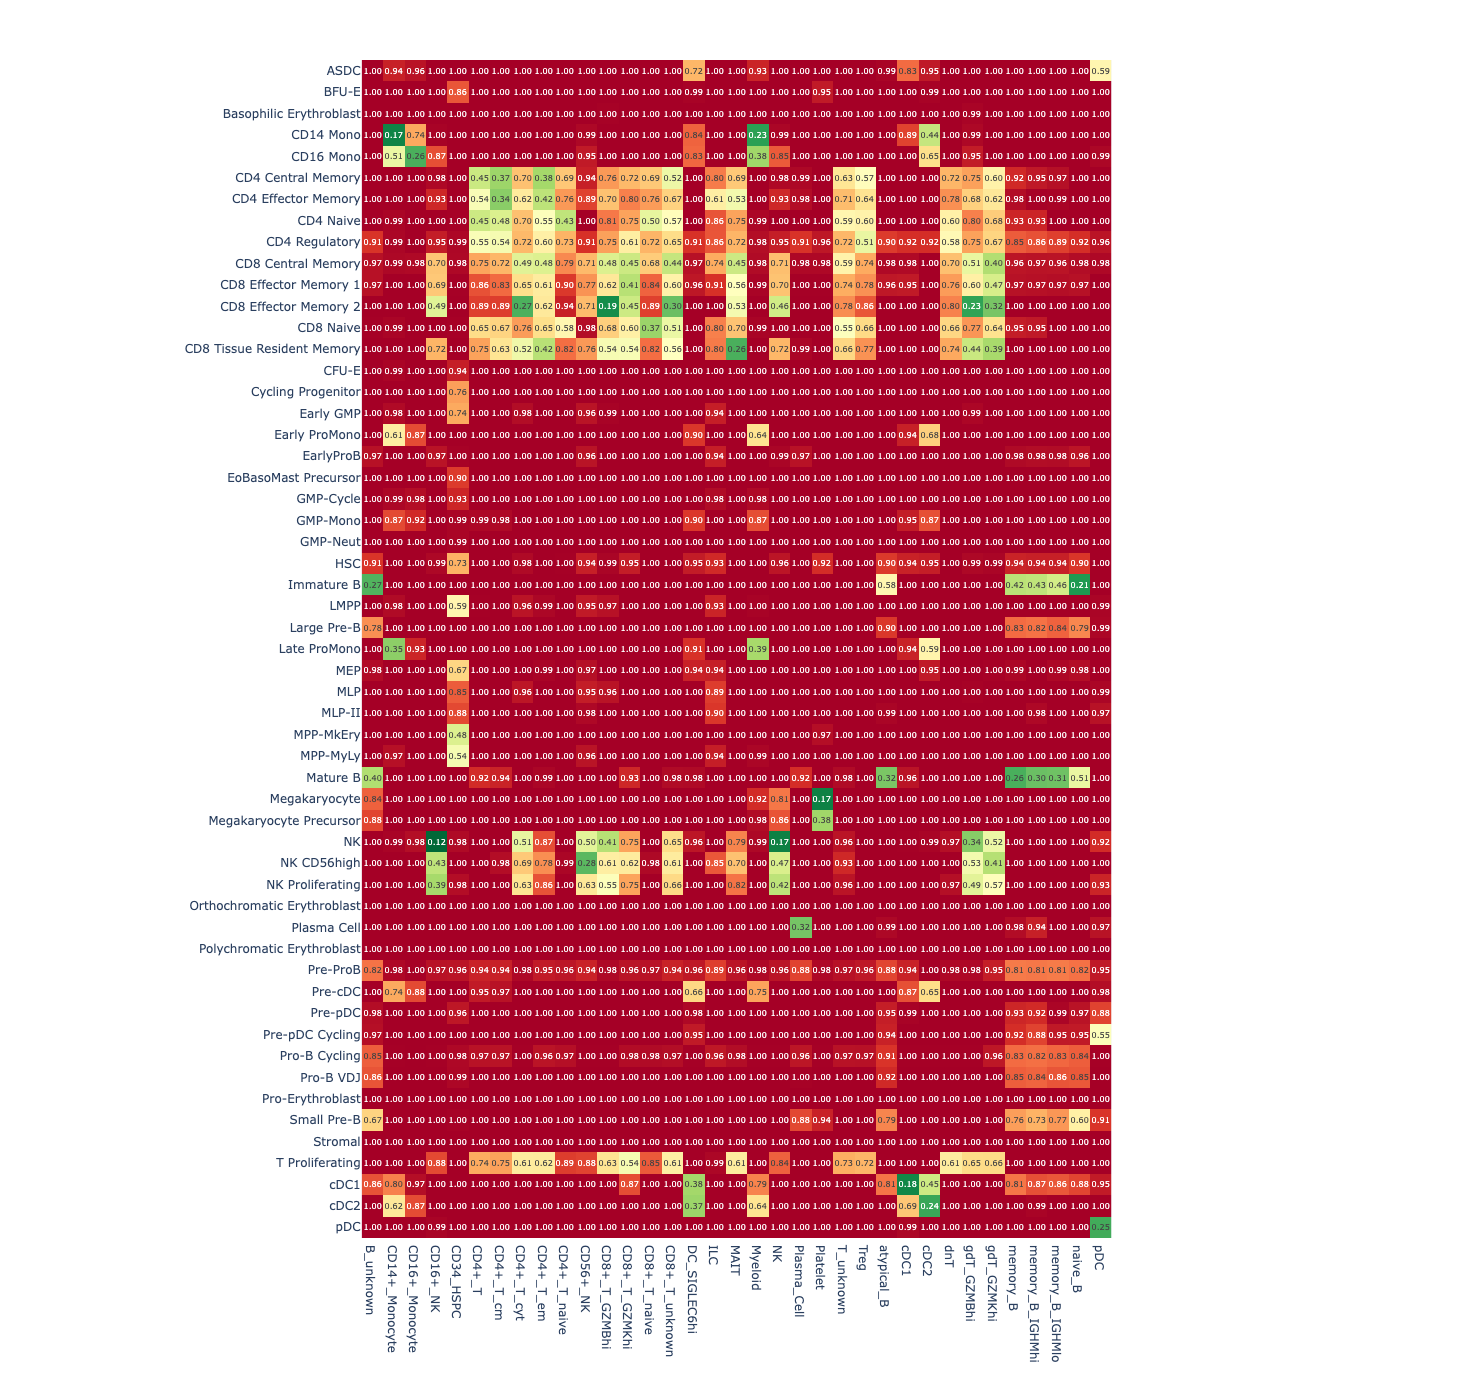

In [224]:
de_gene_overlap = de_gene_rank_difference_distance(
    adata_query,
    adata_ref,
    n_genes_ova=10,
    n_genes_ava=3,
    overlap_threshold=0.3,
    overlap_n_genes=10,
    adj_p_val_threshold=0.05,
    auroc_threshold=0.6,
    gene_filtering=True,
)
de_gene_overlap = de_gene_overlap.sort_index().sort_index(axis=1)

fig = plot_cluster_mapping(de_gene_overlap, colormap="RdYlGn_r", show=False)
fig.update_coloraxes(showscale=False)

## Bures-Wasserstein distance in PCA space

In [12]:
from datasim.label_distance import bures_wasserstein_label_distance

In [13]:
bw_distance_128 = bures_wasserstein_label_distance(
    adata_ref.obsm["X_pca"][:, :128],
    adata_query.obsm["X_pca"][:, :128],
    adata_ref.obs.cell_type_author.to_numpy(),
    adata_query.obs.cell_type_author.to_numpy()
)

  0%|          | 0/1870 [00:00<?, ?it/s]

In [ ]:
fig = plot_cluster_mapping(bw_distance_128, colormap="RdYlGn_r", show=False)
fig.update_coloraxes(showscale=False)

## Spearman correlation of centroids

In [15]:
from datasim.label_distance import spearmanr_label_distance

In [16]:
spearmanr_distance = spearmanr_label_distance(
    adata_ref.X,
    adata_query.X,
    adata_ref.obs.cell_type_author.to_numpy(),
    adata_query.obs.cell_type_author.to_numpy()
)

In [ ]:
fig = plot_cluster_mapping(spearmanr_distance, colormap="RdYlGn_r", show=False)
fig.update_coloraxes(showscale=False)